In [1]:
import pandas as pd
import numpy as np
from src.model_pipeline import ModelPipeline

In [2]:
# df_final = pd.read_parquet("data/feature_engineering/debit/v2/df_union_debit_final.parquet")
df_final = pd.read_parquet(
    "data/feature_engineering/debit/v2/df_union_debit_final_20250620.parquet"
)
df_final = df_final.set_index("Transaction Serial No", drop=True)

# Final Drop Columns

In [3]:
all_feats = [
    "CntUnique_CardNo_by_cardAcceptor_cat_L90D",
    "CntUnique_CardNo_by_cardAcceptor_cat_L14D",
    "CntUnique_CardNo_by_cardAcceptor_cat_L1D",
    "CntUnique_CardNo_by_cardAcceptor_cat_L7D",
    "Sum_Amt_L90D",
    "CntUnique_CardNo_by_cardAcceptor_cat_L30D",
    "Sum_Amt_to_cardAcceptor_cat_L90D",
    "CntUnique_CardNo_by_MCC_L14D",
    "TxnCount_to_cardAcceptor_cat_L30D",
    "Sum_Amt_L30D",
    "Sum_Amt_to_cardAcceptor_cat_L30D",
    "TotalTrxAmount15Mi",
    "Transaction Amount",
    "Sum_Amt_L14D",
    "CntUnique_CardNo_by_MCC_L7D",
    "TxnCount_to_cardAcceptor_cat_L14D",
    "TotalTrxAmount10Mi",
    "CntUnique_CardNo_by_MCC_L30D",
    "CntUnique_CardNo_by_MCC_L1D",
    "TotalTrxAmountL5min",
    "TxnCount_L90D",
    "TxnCount_L30D",
    "CntUnique_CardNo_by_MCC_L90D",
    "TxnCount_L14D",
    "Sum_Amt_to_cardAcceptor_cat_L14D",
    "CountTrxTrf",
    "TotalTrxAmountL1D",
    "TxnCount_L7D",
    "TxnCount_to_cardAcceptor_cat_L90D",
    "TxnCount_to_cardAcceptor_cat_L7D",
    "Balance",
    "Sum_Amt_to_cardAcceptor_cat_L7D",
    "TotalTrxAmountTrf2",
    "TotalTrxAmountTrf",
    "CustomerNationality_FE",
    "CntUnique_CardNo_by_cardAcceptor_country_L90D",
    "CntUnique_CardNo_by_cardAcceptor_country_L7D",
    "Avg_Amt_L90D",
    "CntUnique_CardNo_by_cardAcceptor_country_L14D",
    "Max_Amt_to_cardAcceptor_cat_L14D",
    "Max_Amt_to_cardAcceptor_cat_L30D",
    "CustomerAge",
    "Max_Amt_to_cardAcceptor_cat_L90D",
    "CntUnique_CardNo_by_cardAcceptor_country_L1D",
    "Max_Amt_L90D",
    "Avg_Amt_L30D",
    "CntUnique_CardNo_by_cardAcceptor_country_L30D",
    "CntUnique_CardNo_by_cardAcceptor_cat_L1H",
    "Avg_Amt_to_cardAcceptor_cat_L90D",
    "Max_Amt_L14D",
    "Max_Amt_to_cardAcceptor_cat_L7D",
    "Max_Amt_L30D",
    "AccountStatus_FE",
    "CntUnique_CardNo_by_MCC_L1H",
    "Avg_Amt_to_cardAcceptor_cat_L7D",
    "TxnCount_to_MCC_L90D",
    "CustomerSex_FE",
    "time_diff",
    "Max_Amt_L7D",
    "TxnCount_to_cardAcceptor_cat_L1D",
    "Sum_Amt_to_cardAcceptor_cat_L1D",
    "Max_Amt_L1D",
    "Avg_Amt_L1H",
    "Max_Amt_L1H",
    "TransactionType_FE",
    "Sum_Amt_to_MCC_L90D",
    "POSMode_FE",
    "HIghRiskCustomer_FE",
    "Avg_Amt_L1D",
    "Avg_Amt_to_cardAcceptor_cat_L1D",
    "TxnCount_L1D",
    "CardProduct_FE",
    "Max_Amt_to_cardAcceptor_cat_L1D",
    "CardStatus_FE",
    "Max_Amt_to_MCC_L90D",
    "Avg_Amt_to_MCC_L90D",
    "CntUnique_CardNo_by_cardAcceptor_country_L1H",
    "Max_Amt_L15M",
    "Sum_Amt_to_cardAcceptor_cat_L1H",
    "Max_Amt_to_CountryCode_L90D",
    "TxnCount_to_MCC_L30D",
    "Avg_Amt_to_MCC_L14D",
    "Avg_Amt_to_CountryCode_L1D",
    "TxnCount_to_MCC_L14D",
    "Max_Amt_to_MCC_L30D",
    "IsBillPayment",
    "Avg_Amt_L15M",
    "Avg_Amt_to_MCC_L7D",
    "Max_Amt_to_cardAcceptor_country_L14D",
    "Avg_Amt_to_cardAcceptor_cat_L1H",
    "Max_Amt_to_cardAcceptor_cat_L1H",
    "Avg_Amt_to_MCC_L30D",
    "Sum_Amt_to_cardAcceptor_cat_L15M",
    "Sum_Amt_to_MCC_cat_L30D",
    "Max_Amt_to_MCC_L14D",
    "Max_Amt_to_MCC_L7D",
    "Max_Amt_to_CountryCode_L14D",
    "Sum_Amt_to_MCC_L30D",
    "Max_Amt_to_cardAcceptor_country_L90D",
    "CntUnique_CardNo_by_cardAcceptor_cat_L15M",
    "PINEntryCapability_FE",
    "Sum_Amt_to_MCC_L14D",
    "Sum_Amt_to_MCC_L7D",
    "Avg_Amt_to_cardAcceptor_country_L30D",
    "TxnCount_to_MCC_cat_L90D",
    "CntUnique_CardNo_by_MCC_L15M",
    "TotalTrxAmountTopUp2",
    "TxnCount_to_MCC_catcode_L90D",
    "Max_Amt_to_CountryCode_L1D",
    "Avg_Amt_to_CountryCode_L90D",
    "Avg_Amt_to_cardAcceptor_country_L90D",
    "TotalTrxAmountVA1",
    "Avg_Amt_to_CountryCode_L30D",
    "Max_Amt_to_cardAcceptor_cat_L15M",
    "Country Code_FE",
    "VCardDataInputCapability_FE",
    "Avg_Amt_to_cardAcceptor_country_L1D",
    "Sum_Amt_to_CountryCode_L14D",
    "Sum_Amt_to_CountryCode_L90D",
    "Sum_Amt_to_cardAcceptor_country_L90D",
    "Sum_Amt_to_CountryCode_L30D",
    "TxnCount_to_MCC_cat_L30D",
    "Avg_Amt_to_cardAcceptor_cat_L15M",
    "Avg_Amt_to_cardAcceptor_country_L14D",
    "Cat Card Acceptor Name_FE",
    "TxnCount_to_MCC_catcode_L14D",
    "Avg_Amt_to_CountryCode_L14D",
    "AgeOfOpenAcctTxn",
    "Max_Amt_to_cardAcceptor_country_L30D",
    "Max_Amt_to_CountryCode_L7D",
    "TxnCount_to_cardAcceptor_country_L90D",
    "TxnCount_to_CountryCode_L90D",
    "TxnCount_to_MCC_L7D",
    "TotalTrxAmountTopUp1",
    "TxnCount_to_MCC_catcode_L7D",
    "Max_Amt_to_CountryCode_L30D",
    "IsDCashTrx_FE",
    "TxnCount_to_MCC_cat_L14D",
    "Max_Amt_to_cardAcceptor_country_L1D",
    "Avg_Amt_to_MCC_cat_L30D",
    "Avg_Amt_to_MCC_cat_L90D",
    "TxnCount_to_MCC_catcode_L30D",
    "Avg_Amt_to_MCC_cat_L7D",
    "TxnCount_to_cardAcceptor_country_L30D",
    "Sum_Amt_to_cardAcceptor_country_L1D",
    "IsTopUp",
    "CountTrxTrf2",
    "MCC Category_FE",
    "Sum_Amt_to_cardAcceptor_country_L30D",
    "TxnCount_to_CountryCode_L30D",
    "Sum_Amt_to_cardAcceptor_country_L7D",
    "AccessCode_FE",
    "Avg_Amt_to_CountryCode_L7D",
    "Max_Amt_to_cardAcceptor_country_L1H",
    "Sum_Amt_to_MCC_L1H",
    "TotalTrxAmountContactlessPerDay",
    "Sum_Amt_to_MCC_cat_L14D",
    "IsQRtrx_FE",
    "Avg_Amt_to_MCC_L1D",
    "TotalTrxAmountContactless",
    "TxnCount_to_cardAcceptor_country_L14D",
    "Sum_Amt_to_CountryCode_L7D",
    "Sum_Amt_to_cardAcceptor_country_L14D",
    "Avg_Amt_to_MCC_cat_L1D",
    "TxnCount_to_MCC_cat_L7D",
    "Sum_Amt_to_CountryCode_L1D",
    "Avg_Amt_to_cardAcceptor_country_L1H",
    "Avg_Amt_to_MCC_cat_L14D",
    "Avg_Amt_to_cardAcceptor_country_L7D",
    "Max_Amt_to_cardAcceptor_country_L7D",
    "Avg_Amt_to_CountryCode_L1H",
    "Max_Amt_to_MCC_L1D",
    "TxnCount_to_CountryCode_L14D",
    "TxnCount_to_CountryCode_L7D",
    "Max_Amt_to_CountryCode_L1H",
    "Sum_Amt_to_cardAcceptor_country_L15M",
    "TxnCount_to_cardAcceptor_country_L7D",
    "Sum_Amt_to_MCC_L1D",
    "Max_Amt_to_MCC_L15M",
    "Avg_Amt_to_MCC_L1H",
    "Sum_Amt_to_MCC_L15M",
    "Avg_Amt_to_cardAcceptor_country_L15M",
    "Max_Amt_to_MCC_L1H",
    "Avg_Amt_to_MCC_L15M",
    "Max_Amt_to_cardAcceptor_country_L15M",
    "Max_Amt_to_CountryCode_L15M",
    "Sum_Amt_to_MCC_cat_L15M",
    "TxnCount_to_cardAcceptor_country_L1H",
    "Currency_FE",
    "TxnCount_to_MCC_L15M",
    "TxnCount_to_MCC_L1D",
    "Sum_Amt_to_CountryCode_L1H",
    "TxnCount_to_CountryCode_L1D",
    "TxnCount_to_cardAcceptor_country_L1D",
    "TxnCount_to_cardAcceptor_country_L15M",
    "TxnCount_to_CountryCode_L1H",
    "Avg_Amt_to_MCC_cat_L1H",
    "Sum_Amt_to_CountryCode_L15M",
    "CntUnique_CardNo_by_cardAcceptor_country_L15M",
    "TxnCount_to_MCC_L1H",
    "TxnCount_to_CountryCode_L15M",
    "Sum_Amt_to_MCC_cat_L1H",
    "Avg_Amt_to_CountryCode_L15M",
    "Sum_Amt_to_cardAcceptor_country_L1H",
]

In [3]:
derived_cols = [
    "Avg_Amt_L15M",
    "Avg_Amt_L1D",
    "Avg_Amt_L1H",
    "Avg_Amt_L30D",
    "Avg_Amt_L90D",
    "Avg_Amt_to_CountryCode_L14D",
    "Avg_Amt_to_CountryCode_L15M",
    "Avg_Amt_to_CountryCode_L1D",
    "Avg_Amt_to_CountryCode_L1H",
    "Avg_Amt_to_CountryCode_L30D",
    "Avg_Amt_to_CountryCode_L7D",
    "Avg_Amt_to_CountryCode_L90D",
    "Avg_Amt_to_MCC_L14D",
    "Avg_Amt_to_MCC_L15M",
    "Avg_Amt_to_MCC_L1D",
    "Avg_Amt_to_MCC_L1H",
    "Avg_Amt_to_MCC_L30D",
    "Avg_Amt_to_MCC_L7D",
    "Avg_Amt_to_MCC_L90D",
    "CntUnique_CardNo_by_MCC_L14D",
    "CntUnique_CardNo_by_MCC_L15M",
    "CntUnique_CardNo_by_MCC_L1D",
    "CntUnique_CardNo_by_MCC_L1H",
    "CntUnique_CardNo_by_MCC_L30D",
    "CntUnique_CardNo_by_MCC_L7D",
    "CntUnique_CardNo_by_MCC_L90D",
    "Max_Amt_L14D",
    "Max_Amt_L15M",
    "Max_Amt_L1D",
    "Max_Amt_L1H",
    "Max_Amt_L30D",
    "Max_Amt_L7D",
    "Max_Amt_L90D",
    "Max_Amt_to_CountryCode_L14D",
    "Max_Amt_to_CountryCode_L15M",
    "Max_Amt_to_CountryCode_L1D",
    "Max_Amt_to_CountryCode_L1H",
    "Max_Amt_to_CountryCode_L30D",
    "Max_Amt_to_CountryCode_L7D",
    "Max_Amt_to_CountryCode_L90D",
    "Max_Amt_to_MCC_L14D",
    "Max_Amt_to_MCC_L15M",
    "Max_Amt_to_MCC_L1D",
    "Max_Amt_to_MCC_L1H",
    "Max_Amt_to_MCC_L30D",
    "Max_Amt_to_MCC_L7D",
    "Max_Amt_to_MCC_L90D",
    "Sum_Amt_L14D",
    "Sum_Amt_L30D",
    "Sum_Amt_L90D",
    "Sum_Amt_to_CountryCode_L14D",
    "Sum_Amt_to_CountryCode_L15M",
    "Sum_Amt_to_CountryCode_L1D",
    "Sum_Amt_to_CountryCode_L1H",
    "Sum_Amt_to_CountryCode_L30D",
    "Sum_Amt_to_CountryCode_L7D",
    "Sum_Amt_to_CountryCode_L90D",
    "Sum_Amt_to_MCC_L14D",
    "Sum_Amt_to_MCC_L15M",
    "Sum_Amt_to_MCC_L1D",
    "Sum_Amt_to_MCC_L1H",
    "Sum_Amt_to_MCC_L30D",
    "Sum_Amt_to_MCC_L7D",
    "Sum_Amt_to_MCC_L90D",
    "TxnCount_L15M",
    "TxnCount_L14D",
    "TxnCount_L1D",
    "TxnCount_L30D",
    "TxnCount_L7D",
    "TxnCount_L90D",
    "TxnCount_to_CountryCode_L14D",
    "TxnCount_to_CountryCode_L15M",
    "TxnCount_to_CountryCode_L1D",
    "TxnCount_to_CountryCode_L1H",
    "TxnCount_to_CountryCode_L30D",
    "TxnCount_to_CountryCode_L7D",
    "TxnCount_to_CountryCode_L90D",
    "TxnCount_to_MCC_L14D",
    "TxnCount_to_MCC_L15M",
    "TxnCount_to_MCC_L1D",
    "TxnCount_to_MCC_L1H",
    "TxnCount_to_MCC_L30D",
    "TxnCount_to_MCC_L7D",
    "TxnCount_to_MCC_L90D",
    "time_diff",
    "AvgTrnxHourL15min",
    "AvgTrnxHourL1h",
    "AvgTrnxHourL1d",
    "AvgTrnxHourL14d",
    "AvgTrnxHourL30d",
]

In [4]:
non_derived_cols = [
    # 'AccessCode',
    "AccountStatus",
    "CardProduct",
    # 'CardStatus',
    # 'Cat Card Acceptor Name',
    "CountTrxTrf",
    "Country Code",
    "Currency",
    "CustomerAge",
    # 'CustomerNationality', high-cardinality
    "CustomerSex",
    "HIghRiskCustomer",
    # 'IsDCashTrx', low importance value
    # 'IsQRtrx', low importance value
    # 'MCC Category', low importance value
    # 'PINEntryCapability',
    "POSMode",
    "TotalTrxAmount10Mi",
    "TotalTrxAmount15Mi",
    "TotalTrxAmountL1D",
    "TotalTrxAmountL5min",
    "Transaction Amount",
    "TransactionType",
    # 'VCardDataInputCapability' low importance value
]

In [5]:
selected_derived_cols = [
    col
    for col in derived_cols
    if any(substr in col for substr in ["L15M", "L30D", "L15min", "L30d"])
] + ["time_diff"]

In [6]:
selected_derived_cols

['Avg_Amt_L15M',
 'Avg_Amt_L30D',
 'Avg_Amt_to_CountryCode_L15M',
 'Avg_Amt_to_CountryCode_L30D',
 'Avg_Amt_to_MCC_L15M',
 'Avg_Amt_to_MCC_L30D',
 'CntUnique_CardNo_by_MCC_L15M',
 'CntUnique_CardNo_by_MCC_L30D',
 'Max_Amt_L15M',
 'Max_Amt_L30D',
 'Max_Amt_to_CountryCode_L15M',
 'Max_Amt_to_CountryCode_L30D',
 'Max_Amt_to_MCC_L15M',
 'Max_Amt_to_MCC_L30D',
 'Sum_Amt_L30D',
 'Sum_Amt_to_CountryCode_L15M',
 'Sum_Amt_to_CountryCode_L30D',
 'Sum_Amt_to_MCC_L15M',
 'Sum_Amt_to_MCC_L30D',
 'TxnCount_L15M',
 'TxnCount_L30D',
 'TxnCount_to_CountryCode_L15M',
 'TxnCount_to_CountryCode_L30D',
 'TxnCount_to_MCC_L15M',
 'TxnCount_to_MCC_L30D',
 'AvgTrnxHourL15min',
 'AvgTrnxHourL30d',
 'time_diff']

In [7]:
final_feats = (
    selected_derived_cols + non_derived_cols + ["Transaction Datetime", "Confirmed"]
)

In [8]:
len(selected_derived_cols), len(non_derived_cols), len(
    selected_derived_cols + non_derived_cols
)

(28, 15, 43)

In [9]:
df_final = df_final[final_feats]

## Create Ratio Features

In [10]:
def create_ratio_features(
    df: pd.DataFrame, feature_list: list, default_value: float = -999
) -> pd.DataFrame:
    """
    Automatically creates ratio features of the form L30D, L15M
    for matching base features from the provided feature list
    """
    l15m_feats = {
        col.replace("_L15M", ""): col for col in feature_list if "_L15M" in col
    }
    l30d_feats = {
        col.replace("_L30D", ""): col for col in feature_list if "_L30D" in col
    }

    # find matching base feature names
    matching_bases = set(l15m_feats.keys()) & set(l30d_feats.keys())

    # create ratio columns
    for base in matching_bases:
        col_15m = l15m_feats[base]
        col_30d = l30d_feats[base]
        new_col = f"ratio_{base.lower()}_L30D_L15M"

        # calculate the ratio with save division
        ratio = df[col_30d] / df[col_15m]
        ratio = ratio.replace([np.inf, -np.inf], np.nan)  # handle div by zero

        # fill 0/0 or NaNs or infinities with default value
        df[new_col] = ratio.fillna(default_value)

    return df

In [11]:
df_final = create_ratio_features(df_final, selected_derived_cols)

## Modify CardProduct Grouping

In [12]:
def standardize_to_string_int(val):
    if val == "__missing__":
        return "__missing__"
    try:
        numeric_val = float(val)
        if numeric_val == int(numeric_val):
            return str(int(numeric_val))
        else:
            return str(numeric_val)
    except (ValueError, TypeError):
        return str(val)


def get_card_product_group(val):
    if val == "__missing__":
        return "__missing__"

    s_val = str(val)

    if len(s_val) > 0 and s_val[0].isdigit():
        first_digit = int(s_val[0])
        if 1 <= first_digit <= 7:
            return f"card_product_{first_digit}"
        else:
            return "card_product_other"

    else:
        return "card_product_other"

In [13]:
df_final["CardProduct"] = df_final["CardProduct"].fillna("__missing__")
df_final["CardProduct"] = df_final["CardProduct"].apply(standardize_to_string_int)
df_final["CardProductGrouped"] = df_final["CardProduct"].apply(get_card_product_group)

In [14]:
df_final["CardProductGrouped"] = df_final["CardProductGrouped"].replace(
    {"__missing__": np.nan}
)

## Modify CountryCode

In [15]:
is_whitespace_or_empty = df_final["Country Code"].str.strip() == ""

df_final["Country Code"] = df_final["Country Code"].fillna("__missing__")
df_final["Country Code"] = np.where(
    is_whitespace_or_empty, "__missing__", df_final["Country Code"]
)

In [16]:
specific_country_code = ["IDN", "MYS", "AUS", "SGP"]

df_final["CountryCodeGroup"] = np.where(
    df_final["Country Code"].isin(specific_country_code),
    df_final["Country Code"],
    "others",
)

In [17]:
df_final.drop(["Country Code", "CardProduct"], axis=1, inplace=True)

In [17]:
from src.utils import get_features_by_missing_pct

selected_cols, summary_df = get_features_by_missing_pct(
    df_final, 0.99, ["Transaction Datetime", "Confirmed"]
)

In [18]:
summary_df[~summary_df.feature.isin(["Transaction Datetime", "Confirmed"])].reset_index(
    drop=True
)

,feature,missing_pct
0,Avg_Amt_L15M,0.000000
1,Avg_Amt_L30D,0.000000
2,Avg_Amt_to_CountryCode_L15M,0.848847
3,Avg_Amt_to_CountryCode_L30D,0.848847
4,Avg_Amt_to_MCC_L15M,0.736825
5,Avg_Amt_to_MCC_L30D,0.736825
6,CntUnique_CardNo_by_MCC_L15M,0.802655
7,CntUnique_CardNo_by_MCC_L30D,0.736839
8,Max_Amt_L15M,0.000000
9,Max_Amt_L30D,0.000000


In [18]:
# ratio 1
df_final["RatioTrxAmountL1DL5min"] = (
    df_final["TotalTrxAmountL1D"] / df_final["TotalTrxAmountL5min"]
)
df_final["RatioTrxAmountL1DL5min"] = df_final["RatioTrxAmountL1DL5min"].replace(
    [np.inf, -np.inf], np.nan
)
df_final["RatioTrxAmountL1DL5min"] = df_final["RatioTrxAmountL1DL5min"].fillna(-999)

In [19]:
# ratio 2
df_final["RatioTrxAmountL1DL15min"] = (
    df_final["TotalTrxAmountL1D"] / df_final["TotalTrxAmount15Mi"]
)
df_final["RatioTrxAmountL1DL15min"] = df_final["RatioTrxAmountL1DL15min"].replace(
    [np.inf, -np.inf], np.nan
)
df_final["RatioTrxAmountL1DL15min"] = df_final["RatioTrxAmountL1DL15min"].fillna(-999)

In [20]:
# ratio 3
df_final["RatioTrxAmountL1DL10min"] = (
    df_final["TotalTrxAmountL1D"] / df_final["TotalTrxAmount10Mi"]
)
df_final["RatioTrxAmountL1DL10min"] = df_final["RatioTrxAmountL1DL10min"].replace(
    [np.inf, -np.inf], np.nan
)
df_final["RatioTrxAmountL1DL10min"] = df_final["RatioTrxAmountL1DL10min"].fillna(-999)

In [21]:
# ratio 4
df_final["RatioTrnxHoutL30DL15min"] = (
    df_final["AvgTrnxHourL30d"] / df_final["AvgTrnxHourL15min"]
)
df_final["RatioTrnxHoutL30DL15min"] = df_final["RatioTrnxHoutL30DL15min"].replace(
    [np.inf, -np.inf], np.nan
)
df_final["RatioTrnxHoutL30DL15min"] = df_final["RatioTrnxHoutL30DL15min"].fillna(-999)

In [22]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
Index: 714734 entries, 1047361273 to 1143344726
Data columns (total 61 columns):
 #   Column                                   Non-Null Count   Dtype         
---  ------                                   --------------   -----         
 0   Avg_Amt_L15M                             714734 non-null  float64       
 1   Avg_Amt_L30D                             714734 non-null  float64       
 2   Avg_Amt_to_CountryCode_L15M              108034 non-null  float64       
 3   Avg_Amt_to_CountryCode_L30D              108034 non-null  float64       
 4   Avg_Amt_to_MCC_L15M                      188100 non-null  float64       
 5   Avg_Amt_to_MCC_L30D                      188100 non-null  float64       
 6   CntUnique_CardNo_by_MCC_L15M             141049 non-null  float64       
 7   CntUnique_CardNo_by_MCC_L30D             188090 non-null  float64       
 8   Max_Amt_L15M                             714734 non-null  float64       
 9   Max_Amt_L30D      

In [41]:
df_final.to_parquet("data/ready_to_train/df_debit_final_raw_20250623.parquet")

# Split and Prepare DF

In [23]:
split_date = "2025-05-01"

In [24]:
# setup pipeline
pipeline = ModelPipeline(model_type="random_forest", random_state=42)

df_splits = pipeline.split_data_by_date(
    df=df_final, date_column="Transaction Datetime", split_date=split_date
)

Initializing ModelPipeline with model type: random_forest
Retrieving model instance for type: random_forest
Splitting data by date (pre-preprocessing)...
Train samples: 647760, Test samples: 66974
Data splitting complete.


In [25]:
# prepare TRAIN data
target_col = "Confirmed"
X, y = pipeline.prepare_data(
    df=df_splits["df_train"],
    target_column=target_col,
    exclude_columns=["Transaction Datetime"],
    is_apply_one_hot=True,
    is_apply_log=False,
    is_impute_median=False,
    is_training=True,
)

Preparing data (is_training=True)...
Starting core numeric and boolean preprocessing...
Core numeric and boolean preprocessing complete.
Fitting CategoryManager...
  Fitted categories for column 'AccountStatus': ['1', '2', '3', '6', '7', '8', '__missing__']
  Fitted categories for column 'Currency': ['IDR', '__missing__']
  Fitted categories for column 'CustomerSex': ['F', 'M', '__missing__']
  Fitted categories for column 'HIghRiskCustomer': ['0', 'N', '__missing__']
  Fitted categories for column 'POSMode': ['0', '1', '2', '5', '7', '9', '__missing__']
  Fitted categories for column 'TransactionType': ['0', '1', '23', '31', '4', '40', '50', '51', 'BI', 'CA', 'DC', 'FT', 'IN', 'PA', '__missing__']
  Fitted categories for column 'CardProductGrouped': ['CARD_PRODUCT_1', 'CARD_PRODUCT_2', 'CARD_PRODUCT_3', 'CARD_PRODUCT_4', 'CARD_PRODUCT_5', 'CARD_PRODUCT_6', 'CARD_PRODUCT_7', 'CARD_PRODUCT_OTHER', '__missing__']
  Fitted categories for column 'CountryCodeGroup': ['AUS', 'IDN', 'MYS', 'O

In [26]:
# split data
X_train, X_test, y_train, y_test = pipeline.split_data(X, y, test_size=0.3)

Splitting data into train and test sets...
Data splitting complete.


In [27]:
len(X.columns)

96

# Over-Sampling

In [27]:
from src.imbalance_learn import ImbalancedSampler

In [28]:
# OverSampling
ros_sampler = ImbalancedSampler(
    algorithm="RandomOverSampler",
    sampler_type="upsample",
    target_ratio=0.2,  # 7%
    random_state=1234,
)

X_train_ros, y_train_ros = ros_sampler.fit_resample(X_train, y_train)

Original dataset shape: Counter({0.0: 453118, 1.0: 314})
Resampled dataset shape using RandomOverSampler: Counter({0.0: 453118, 1.0: 90623})


# Model Fit

In [29]:
# build and trai0_n
pipeline.build_pipeline()
pipeline.train(X_train_ros, y_train_ros, show_training_log=False)

Building pipeline...
Pipeline built.
Training model...
Model training complete.


In [30]:
base_rf_ros = pipeline.get_model()

Returning trained model...


In [31]:
import pickle

filepath = "model/debit/base_rf_ros_96_feats_20250623.pkl"
with open(filepath, "wb") as f:
    pickle.dump(base_rf_ros, f)

In [32]:
# Evaluate
test_results = pipeline.evaluate(X_test, y_test)

Evaluating model...
Accuracy: 0.9817
AUC: 0.9696
PR AUC: 0.0994
Precision: 0.0244
Recall: 0.6519

Classification Report:
               precision    recall  f1-score   support

         0.0       1.00      0.98      0.99    194193
         1.0       0.02      0.65      0.05       135

    accuracy                           0.98    194328
   macro avg       0.51      0.82      0.52    194328
weighted avg       1.00      0.98      0.99    194328



### SMOTE Train

In [41]:
# SMOTE
# OverSampling
smote_sampler = ImbalancedSampler(
    algorithm="SMOTE",
    sampler_type="upsample",
    target_ratio=0.2,  # 7%
    random_state=1234,
)

X_train_smote, y_train_smote = smote_sampler.fit_resample(X_train, y_train)

pipeline.train(X_train_smote, y_train_smote, show_training_log=False)

Original dataset shape: Counter({0.0: 453118, 1.0: 314})


C:\Users\Administrator\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
found 0 physical cores < 1
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\Administrator\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 282, in _count_physical_cores
    raise ValueError(f"found {cpu_count_physical} physical cores < 1")


Resampled dataset shape using SMOTE: Counter({0.0: 453118, 1.0: 90623})
Training model...
Model training complete.


In [42]:
# Evaluate
smote_test_results = pipeline.evaluate(X_test, y_test)

Evaluating model...
Accuracy: 0.9896
AUC: 0.9697
PR AUC: 0.1202
Precision: 0.0377
Recall: 0.5704

Classification Report:
               precision    recall  f1-score   support

         0.0       1.00      0.99      0.99    194193
         1.0       0.04      0.57      0.07       135

    accuracy                           0.99    194328
   macro avg       0.52      0.78      0.53    194328
weighted avg       1.00      0.99      0.99    194328



In [43]:
base_rf_smote = pipeline.get_model()

Returning trained model...


# Eval Model

In [38]:
from src.utils import plot_confusion_matrix

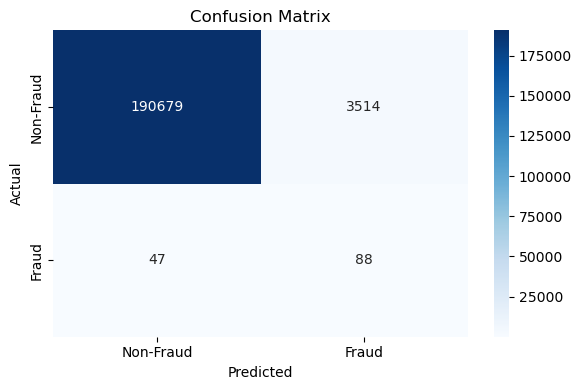

Recall/True Positive Rate: The model got 65.19% of correctly predicted fraud from all of the actual fraud transactions
Precision: The model got 2.44% of correctly predicted fraud from all transactions that predicted as fraud
False Positive Rate: The model got 1.81% of incorrectly predicted a fraud transactions when the actual transactions is non-fraud


In [39]:
y_prob = base_rf_ros.predict_proba(X_test)[:, 1]
plot_confusion_matrix(y_test, y_prob, 0.5)

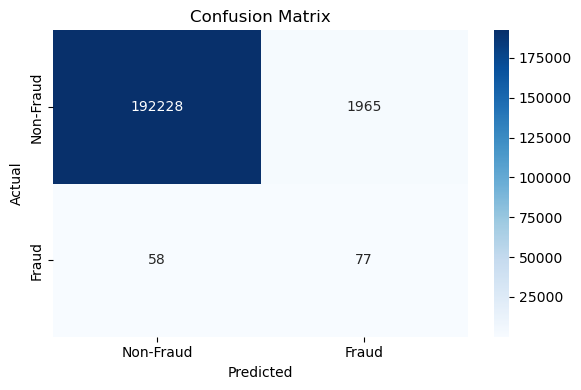

Recall/True Positive Rate: The model got 57.04% of correctly predicted fraud from all of the actual fraud transactions
Precision: The model got 3.77% of correctly predicted fraud from all transactions that predicted as fraud
False Positive Rate: The model got 1.01% of incorrectly predicted a fraud transactions when the actual transactions is non-fraud


In [44]:
y_prob = base_rf_smote.predict_proba(X_test)[:, 1]
plot_confusion_matrix(y_test, y_prob, 0.5)

# Back-Testing with OOS Data

In [33]:
df_debit_mix = pd.read_parquet("data/base/df_debit_clean_v2.parquet")
trx_id_list = list(
    df_debit_mix[df_debit_mix.Confirmed.isin([0, 1])]["Transaction Serial No"]
)
df_oos_new = df_splits["df_test"][df_splits["df_test"].index.isin(trx_id_list)]

In [34]:
X_oos, y_oos = pipeline.prepare_data(
    df=df_splits["df_test"],
    # df=df_oos_new,
    target_column=target_col,
    exclude_columns=["Transaction Datetime"],
    is_apply_one_hot=True,
    is_apply_log=False,
    is_impute_median=False,
    is_training=False,
)

Preparing data (is_training=False)...
Starting core numeric and boolean preprocessing...
Core numeric and boolean preprocessing complete.
Transforming data using CategoryManager...
CategoryManager transformation complete.
Applying One-Hot Encoders for column: Index(['AccountStatus', 'Currency', 'CustomerSex', 'HIghRiskCustomer',
       'POSMode', 'TransactionType', 'CardProductGrouped', 'CountryCodeGroup'],
      dtype='object')...
Identified numerical columns for imputation: ['Avg_Amt_L15M', 'Avg_Amt_L30D', 'Avg_Amt_to_CountryCode_L15M', 'Avg_Amt_to_CountryCode_L30D', 'Avg_Amt_to_MCC_L15M', 'Avg_Amt_to_MCC_L30D', 'CntUnique_CardNo_by_MCC_L15M', 'CntUnique_CardNo_by_MCC_L30D', 'Max_Amt_L15M', 'Max_Amt_L30D', 'Max_Amt_to_CountryCode_L15M', 'Max_Amt_to_CountryCode_L30D', 'Max_Amt_to_MCC_L15M', 'Max_Amt_to_MCC_L30D', 'Sum_Amt_L30D', 'Sum_Amt_to_CountryCode_L15M', 'Sum_Amt_to_CountryCode_L30D', 'Sum_Amt_to_MCC_L15M', 'Sum_Amt_to_MCC_L30D', 'TxnCount_L15M', 'TxnCount_L30D', 'TxnCount_to_Cou

In [35]:
len(X.columns)

95

In [36]:
# Evaluate ALL trx
oos_results = pipeline.evaluate(X_oos, y_oos)

Evaluating model...
Accuracy: 0.9845
AUC: 0.9836
PR AUC: 0.0922
Precision: 0.0302
Recall: 0.8205

Classification Report:
               precision    recall  f1-score   support

         0.0       1.00      0.98      0.99     66935
         1.0       0.03      0.82      0.06        39

    accuracy                           0.98     66974
   macro avg       0.52      0.90      0.53     66974
weighted avg       1.00      0.98      0.99     66974



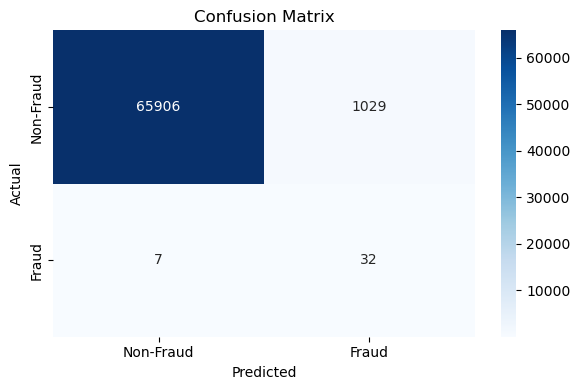

Recall/True Positive Rate: The model got 82.05% of correctly predicted fraud from all of the actual fraud transactions
Precision: The model got 3.02% of correctly predicted fraud from all transactions that predicted as fraud
False Positive Rate: The model got 1.54% of incorrectly predicted a fraud transactions when the actual transactions is non-fraud


In [40]:
y_oos_prob = base_rf_ros.predict_proba(X_oos)[:, 1]
plot_confusion_matrix(y_oos, y_oos_prob, 0.5)

### SMOTE Eval

In [45]:
# Evaluate ALL trx
smote_oos_results = pipeline.evaluate(X_oos, y_oos)

Evaluating model...
Accuracy: 0.9914
AUC: 0.9824
PR AUC: 0.1022
Precision: 0.0471
Recall: 0.7179

Classification Report:
               precision    recall  f1-score   support

         0.0       1.00      0.99      1.00     66935
         1.0       0.05      0.72      0.09        39

    accuracy                           0.99     66974
   macro avg       0.52      0.85      0.54     66974
weighted avg       1.00      0.99      1.00     66974



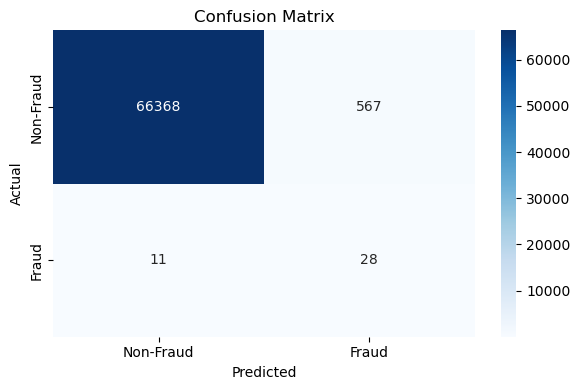

Recall/True Positive Rate: The model got 71.79% of correctly predicted fraud from all of the actual fraud transactions
Precision: The model got 4.71% of correctly predicted fraud from all transactions that predicted as fraud
False Positive Rate: The model got 0.85% of incorrectly predicted a fraud transactions when the actual transactions is non-fraud


In [46]:
y_oos_prob = base_rf_smote.predict_proba(X_oos)[:, 1]
plot_confusion_matrix(y_oos, y_oos_prob, 0.5)

# Feature Importance

In [41]:
# Feature importance
importance_df = pipeline.get_feature_importance(X_train_ros, y_train_ros)

Getting feature importances...
  Using native feature importances.


In [43]:
pd.set_option("display.max_rows", None)
importance_df["importance"] = np.round(importance_df["importance"], 6)
importance_df

,feature,importance
2,Sum_Amt_L30D,0.132834
5,TxnCount_L30D,0.104626
6,CountTrxTrf,0.080366
8,TotalTrxAmount10Mi,0.065399
1,CntUnique_CardNo_by_MCC_L30D,0.064568
9,TotalTrxAmount15Mi,0.060416
12,Transaction Amount,0.059537
10,TotalTrxAmountL1D,0.057127
11,TotalTrxAmountL5min,0.053032
7,CustomerAge,0.044422


# Eval ALERT Transactions Only

In [ ]:
# Evaluate ALERT trx only
X_oos_new, y_oos_new = pipeline.prepare_data(
    # df=df_splits["df_test"],
    df=df_oos_new,
    target_column=target_col,
    exclude_columns=["Transaction Datetime"],
    is_training=False,  # set to False for back-testing/predicting OOS data
)

In [ ]:
# Evaluate ALERT trx only
oos_results = pipeline.evaluate(X_oos_new, y_oos_new)

In [ ]:
y_oos_new_prob = pipeline.pipeline.predict_proba(X_oos_new)[:, 1]
plot_confusion_matrix(y_oos_new, y_oos_new_prob, 0.5)